In [ ]:
from mistune import html
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def make_df(cols, ind):
    data = {c: [str(c) + str(i) for i in ind]
            for c in cols}
    return pd.DataFrame(data, ind)

time stamp: particular moment in time

time intervals and periods: duration of time between two points (periods are fixed usually, intervals are not)

time deltas or durations: length of time

# Dates and Times in Python

## Native Python Dates and Times
flexible syntax. large numbers of values will take some time, so numpy and pandas are better for large datasets.

In [50]:
from datetime import datetime
from dateutil import parser

print(datetime.now())
print(parser.parse("2024-06-01"))

2026-07-12 22:47:27.731923
2024-06-01 00:00:00


## Types arrays of times: Numpy's datetime64

In [51]:
np.array('2024-06-01', dtype='datetime64') + np.arange(10)

array(['2024-06-01', '2024-06-02', '2024-06-03', '2024-06-04',
       '2024-06-05', '2024-06-06', '2024-06-07', '2024-06-08',
       '2024-06-09', '2024-06-10'], dtype='datetime64[D]')

In [52]:
np.datetime64('2024-06-01 12:00:50.123456')

np.datetime64('2024-06-01T12:00:50.123456')

## dates and times in pandas

In [53]:
pd.to_datetime("2024-06-01")

Timestamp('2024-06-01 00:00:00')

In [54]:
pd.to_datetime("2024-06-01 12:00:50") + pd.to_timedelta(np.arange(6), 'W')

DatetimeIndex(['2024-06-01 12:00:50', '2024-06-08 12:00:50',
               '2024-06-15 12:00:50', '2024-06-22 12:00:50',
               '2024-06-29 12:00:50', '2024-07-06 12:00:50'],
              dtype='datetime64[us]', freq=None)

# pandas time series: indexing by time

In [ ]:
index = pd.DatetimeIndex(['2024-07-01', '2024-06-02',
    '2024-08-03', '2024-06-04', '2024-06-05', '2024-07-06'])
df = pd.Series([0, 1, 2, 3, 4, 5], index=index).sort_index()
print(df, "\n")
print(df['2024-06-04'], "\n")
print(df['2024-06-01':'2024-07-01'], "\n")
print(df['2024-06'])

2024-06-02    1
2024-06-04    3
2024-06-05    4
2024-07-01    0
2024-07-06    5
2024-08-03    2
dtype: int64 

3 

2024-06-02    1
2024-06-04    3
2024-06-05    4
2024-07-01    0
dtype: int64 

2024-06-02    1
2024-06-04    3
2024-06-05    4
dtype: int64


# pandas time series data structures
timestamps: `Timestamp`. replaces python's `datetime` object. structure is `DatetimeIndex` for arrays of timestamps.

time periods: `Period`. replaces python's `datetime` object. structure is `PeriodIndex` for arrays of periods.

time deltas or durations: `Timedelta`. replaces python's `timedelta` object. structure is `TimedeltaIndex` for arrays of durations.

In [67]:
dates = pd.to_datetime([datetime(2024, 6, 1), '2032-06-01', '2024/06/01', 1234567890, pd.Timestamp('2024-06-01')])
print(dates, '\n')
print(dates.copy().to_period('W'), '\n')
print(dates - pd.Timestamp('2024-06-01'))

DatetimeIndex([          '2024-06-01 00:00:00',
                         '2032-06-01 00:00:00',
                         '2024-06-01 00:00:00',
               '1970-01-01 00:00:01.234567890',
                         '2024-06-01 00:00:00'],
              dtype='datetime64[ns]', freq=None) 

PeriodIndex(['2024-05-27/2024-06-02', '2032-05-31/2032-06-06',
             '2024-05-27/2024-06-02', '1969-12-29/1970-01-04',
             '2024-05-27/2024-06-02'],
            dtype='period[W-SUN]') 

TimedeltaIndex([                '0 days 00:00:00',
                             '2922 days 00:00:00',
                                '0 days 00:00:00',
                '-19875 days +00:00:01.234567890',
                                '0 days 00:00:00'],
               dtype='timedelta64[ns]', freq=None)


In [57]:
dates.copy().to_period('W')

PeriodIndex(['2024-05-27/2024-06-02', '2032-05-31/2032-06-06',
                               'NaT', '2024-05-27/2024-06-02',
             '1969-12-29/1970-01-04', '2024-05-27/2024-06-02'],
            dtype='period[W-SUN]')

## time delta

In [58]:
dates - pd.Timestamp('2024-06-01')

TimedeltaIndex([                '0 days 00:00:00',
                             '2922 days 00:00:00',
                                              NaT,
                                '0 days 00:00:00',
                '-19875 days +00:00:01.234567890',
                                '0 days 00:00:00'],
               dtype='timedelta64[ns]', freq=None)

## regular sequences date_range

In [70]:
print(pd.date_range('2024-06-01', periods=10, freq='W'), "\n")
print(pd.date_range('2025-06-01', '2027-06-01', freq='ME'), "\n")
print(pd.date_range('2024-06-01', periods=10))

DatetimeIndex(['2024-06-02', '2024-06-09', '2024-06-16', '2024-06-23',
               '2024-06-30', '2024-07-07', '2024-07-14', '2024-07-21',
               '2024-07-28', '2024-08-04'],
              dtype='datetime64[us]', freq='W-SUN') 

DatetimeIndex(['2025-06-30', '2025-07-31', '2025-08-31', '2025-09-30',
               '2025-10-31', '2025-11-30', '2025-12-31', '2026-01-31',
               '2026-02-28', '2026-03-31', '2026-04-30', '2026-05-31',
               '2026-06-30', '2026-07-31', '2026-08-31', '2026-09-30',
               '2026-10-31', '2026-11-30', '2026-12-31', '2027-01-31',
               '2027-02-28', '2027-03-31', '2027-04-30', '2027-05-31'],
              dtype='datetime64[us]', freq='ME') 

DatetimeIndex(['2024-06-01', '2024-06-02', '2024-06-03', '2024-06-04',
               '2024-06-05', '2024-06-06', '2024-06-07', '2024-06-08',
               '2024-06-09', '2024-06-10'],
              dtype='datetime64[us]', freq='D')


# frequencies and offsets

In [71]:
print(pd.timedelta_range(0, periods=10, freq='5D'))

TimedeltaIndex([ '0 days',  '5 days', '10 days', '15 days', '20 days',
                '25 days', '30 days', '35 days', '40 days', '45 days'],
               dtype='timedelta64[ns]', freq='5D')


# resampling, shifting, and windowing

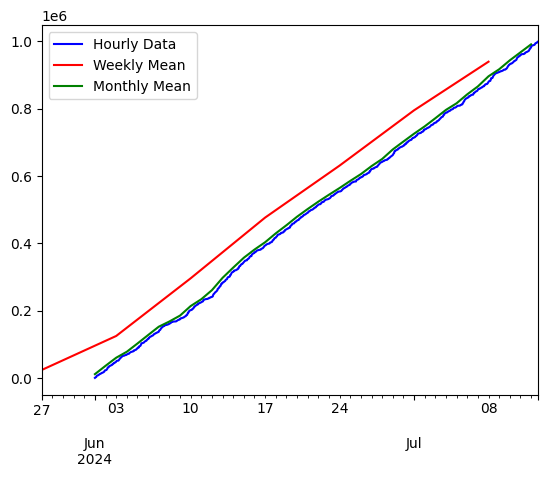

In [61]:
times = pd.date_range('2024-06-01', periods=1000, freq='h')
data = np.sort(np.random.choice(range(0, 1_000_000, 10), size=1000))
series = pd.Series(data, index=times)
series.plot(color='blue', label='Hourly Data')
series.resample('W').mean().plot(color='red', label='Weekly Mean')
series.resample('D').mean().plot(color='green', label='Monthly Mean')
plt.legend()

## time shifts
if not freq is specified, the shift will be in terms of the index, not time. if freq is specified, the shift will be in terms of time.

In [92]:
times = pd.date_range('2024-06-01', periods=5)
data = pd.Series(np.random.randn(5), index=times)
print(data, "\n")
print(data.shift(2), "\n")
print(data.shift(2, freq='W'))

2024-06-01   -1.538647
2024-06-02    1.085106
2024-06-03    2.080451
2024-06-04    0.530132
2024-06-05    0.332461
Freq: D, dtype: float64 

2024-06-01         NaN
2024-06-02         NaN
2024-06-03   -1.538647
2024-06-04    1.085106
2024-06-05    2.080451
Freq: D, dtype: float64 

2024-06-09   -1.538647
2024-06-16    1.085106
2024-06-16    2.080451
2024-06-16    0.530132
2024-06-16    0.332461
dtype: float64


## rolling windows

specify a number of entries to use for each average

# Example with realistic data

<Axes: xlabel='x', ylabel='y'>

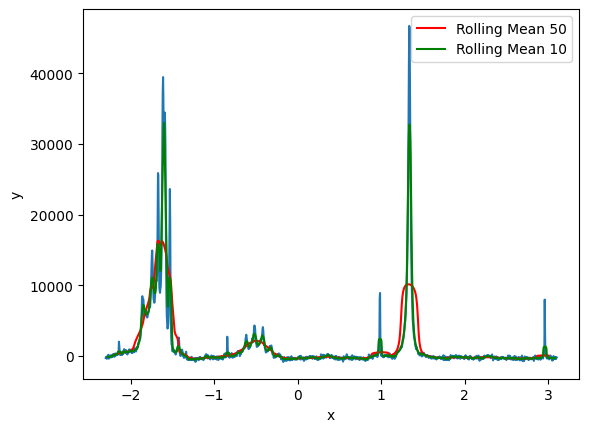

In [63]:
df = pd.read_csv('testdata.dat', sep = ' ', header=None, names=['x', 'y'])[::-1]
sns.lineplot(data=df, x='x', y='y')
df['rolling50'] = df['y'].rolling(50, center=True).mean()
df['rolling10'] = df['y'].rolling(10, center=True).mean()
sns.lineplot(data=df, x='x', y='rolling50', label='Rolling Mean 50', color='red')
sns.lineplot(data=df, x='x', y='rolling10', label='Rolling Mean 10', color='green')